In [3]:
import cfusdlog
import numpy as np
import matplotlib.pyplot as plt

In [4]:
file_path = "logs_crazyflie/ctrlRL04"

decoded_data = cfusdlog.decode(file_path)
for key, values in decoded_data["fixedFrequency"].items():
    print(f"{key}")  # Print shape of the values

print("Num keys: ", len(decoded_data["fixedFrequency"].keys()))

timestamp
ctrlRL.obs_0
ctrlRL.obs_1
ctrlRL.obs_2
ctrlRL.obs_3
ctrlRL.obs_4
ctrlRL.obs_5
ctrlRL.obs_6
ctrlRL.obs_7
ctrlRL.obs_8
ctrlRL.obs_9
ctrlRL.obs_10
ctrlRL.obs_11
ctrlRL.obs_12
ctrlRL.obs_13
ctrlRL.obs_14
ctrlRL.obs_15
ctrlRL.obs_16
ctrlRL.obs_17
ctrlRL.obs_18
ctrlRL.obs_19
Num keys:  21


In [14]:
pos_file_path = "logs_crazyflie/obs_position"
rot_file_path = "logs_crazyflie/obs_rotation_3"
vel_file_path = "logs_crazyflie/obs_grav_velocities"

pos_data = cfusdlog.decode(pos_file_path)
rot_data = cfusdlog.decode(rot_file_path)
vel_data = cfusdlog.decode(vel_file_path)

print("Position keys:", len(pos_data["fixedFrequency"].keys()), pos_data["fixedFrequency"].keys())
print("Rotation keys:", len(rot_data["fixedFrequency"].keys()), rot_data["fixedFrequency"].keys())
print("Velocity keys:", len(vel_data["fixedFrequency"].keys()), vel_data["fixedFrequency"].keys())

Position keys: 10 dict_keys(['timestamp', 'ctrlRL.obs_0', 'ctrlRL.obs_1', 'ctrlRL.obs_2', 'stateEstimate.x', 'stateEstimate.y', 'stateEstimate.z', 'stateEstimate.qx', 'stateEstimate.qy', 'stateEstimate.qz'])
Rotation keys: 18 dict_keys(['timestamp', 'ctrlRL.obs_3', 'ctrlRL.obs_4', 'ctrlRL.obs_5', 'ctrlRL.obs_6', 'ctrlRL.obs_7', 'ctrlRL.obs_8', 'ctrlRL.obs_9', 'ctrlRL.obs_10', 'ctrlRL.obs_11', 'stateEstimate.qx', 'stateEstimate.qy', 'stateEstimate.qz', 'stateEstimate.qw', 'ctrltarget.qx', 'ctrltarget.qy', 'ctrltarget.qz', 'ctrltarget.qw'])
Velocity keys: 19 dict_keys(['timestamp', 'ctrlRL.obs_12', 'ctrlRL.obs_13', 'ctrlRL.obs_14', 'ctrlRL.obs_15', 'ctrlRL.obs_16', 'ctrlRL.obs_17', 'ctrlRL.obs_18', 'ctrlRL.obs_19', 'ctrlRL.obs_20', 'stateEstimate.vx', 'stateEstimate.vy', 'stateEstimate.vz', 'stateEstimate.qx', 'stateEstimate.qy', 'stateEstimate.qz', 'stateEstimate.qw', 'gyro.x', 'gyro.y'])


In [39]:
timestamps = decoded_data["fixedFrequency"]["timestamp"] / 1000
timestamp_diff = np.diff(timestamps)
print("Timestamps:", timestamps)
print("Timestamp differences (ms):", timestamp_diff * 1000)  # Convert to milliseconds


Timestamps: [22.555139 22.565044 22.574944 22.58485  22.594754 22.604663 22.614566
 22.624472 22.634379 22.644292 22.654188 22.664094 22.674006 22.683911
 22.693811 22.703718 22.713623 22.723533 22.733434 22.74334  22.753251
 22.763158 22.77306  22.782964 22.792872 22.802779 22.81268  22.822586
 22.832492 22.842404 22.852305 22.86221  22.872117 22.882025 22.891926
 22.901833 22.911746 22.921648 22.93155  22.941462 22.951361 22.961271
 22.971176 22.981079 22.990986 23.000899 23.010807 23.02071  23.030615
 23.040526 23.050433 23.060333 23.07024  23.08015  23.090058 23.099957
 23.109863 23.119779 23.129673 23.139582 23.149481 23.159392 23.169294
 23.179204 23.189103 23.199022 23.208921 23.218818 23.228732 23.238633
 23.248537 23.258443 23.268351 23.278261 23.288162 23.298067 23.307975
 23.317884 23.327782 23.337686 23.347592 23.357503 23.367403 23.377309
 23.387218 23.397124 23.407032 23.416933 23.426838 23.436752 23.44665
 23.456565 23.466462 23.476376 23.486278 23.496178 23.506084 23.51

In [40]:
cmd_thrust = decoded_data["fixedFrequency"]["ctrlRL.cmd_thrust"]
cmd_roll = decoded_data["fixedFrequency"]["ctrlRL.cmd_roll"]
cmd_pitch = decoded_data["fixedFrequency"]["ctrlRL.cmd_pitch"]
cmd_yaw = decoded_data["fixedFrequency"]["ctrlRL.cmd_yaw"]

plt.figure(figsize=(10, 6))
plt.plot(cmd_thrust, label='Thrust')
plt.plot(cmd_roll, label='Roll')
plt.plot(cmd_pitch, label='Pitch')
plt.plot(cmd_yaw, label='Yaw')
plt.xlabel('Time (s)')
plt.ylabel('Command Value')
plt.title('Control Commands Over Time')
plt.legend()
plt.grid()
plt.show()

KeyError: 'ctrlRL.cmd_thrust'

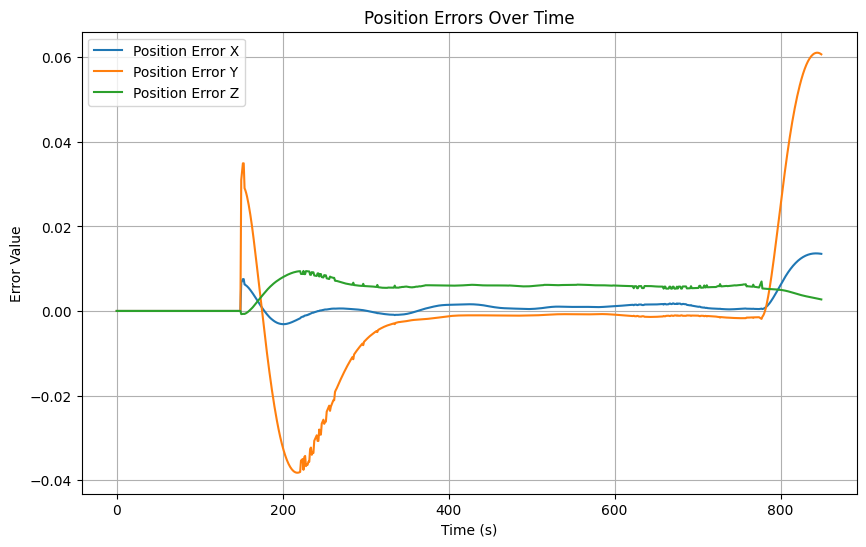

In [27]:
e_x = decoded_data["fixedFrequency"]["ctrlRL.epos_x"]
e_y = decoded_data["fixedFrequency"]["ctrlRL.epos_y"]
e_z = decoded_data["fixedFrequency"]["ctrlRL.epos_z"]

plt.figure(figsize=(10, 6))
plt.plot(e_x, label='Position Error X')
plt.plot(e_y, label='Position Error Y')
plt.plot(e_z, label='Position Error Z')
plt.xlabel('Time (s)')
plt.ylabel('Error Value')
plt.title('Position Errors Over Time')
plt.legend()
plt.grid()
plt.show()

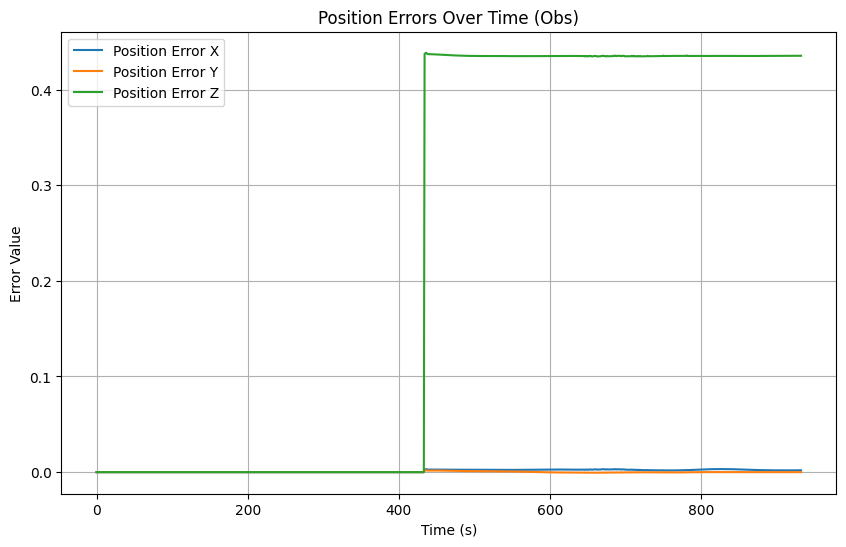

In [7]:
pos_error_x = pos_data["fixedFrequency"]["ctrlRL.obs_0"]
pos_error_y = pos_data["fixedFrequency"]["ctrlRL.obs_1"]
pos_error_z = pos_data["fixedFrequency"]["ctrlRL.obs_2"]

plt.figure(figsize=(10, 6))
plt.plot(pos_error_x, label='Position Error X')
plt.plot(pos_error_y, label='Position Error Y')
plt.plot(pos_error_z, label='Position Error Z')
plt.xlabel('Time (s)')
plt.ylabel('Error Value')
plt.title('Position Errors Over Time (Obs)')
plt.legend()
plt.grid()
plt.show()

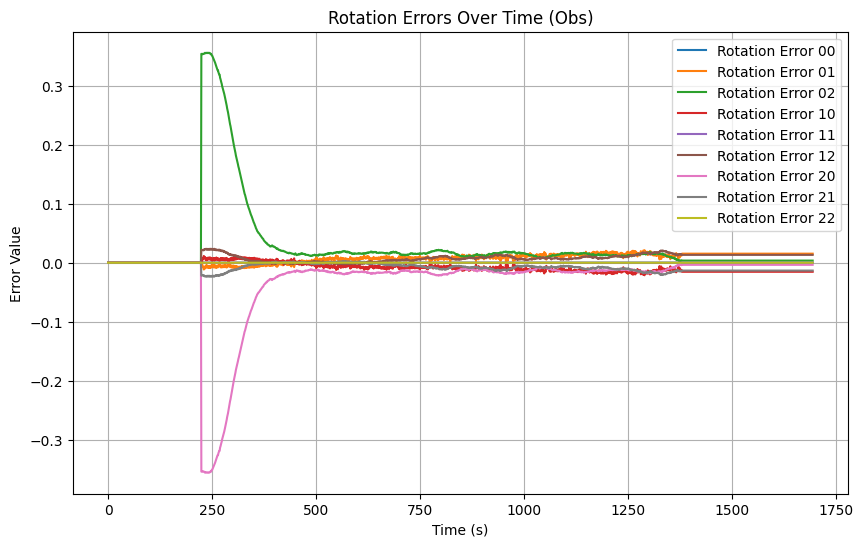

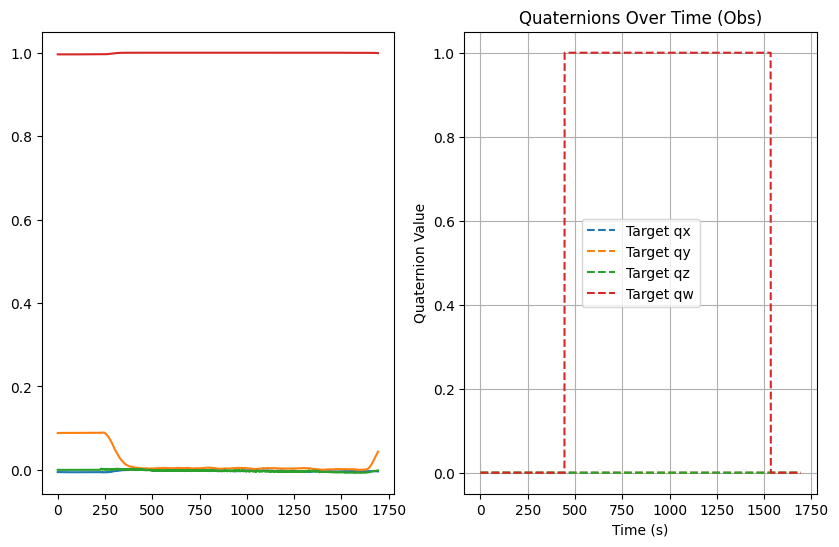

In [15]:
rot_error_00 = rot_data["fixedFrequency"]["ctrlRL.obs_3"]
rot_error_01 = rot_data["fixedFrequency"]["ctrlRL.obs_4"]
rot_error_02 = rot_data["fixedFrequency"]["ctrlRL.obs_5"]
rot_error_10 = rot_data["fixedFrequency"]["ctrlRL.obs_6"]
rot_error_11 = rot_data["fixedFrequency"]["ctrlRL.obs_7"]
rot_error_12 = rot_data["fixedFrequency"]["ctrlRL.obs_8"]
rot_error_20 = rot_data["fixedFrequency"]["ctrlRL.obs_9"]
rot_error_21 = rot_data["fixedFrequency"]["ctrlRL.obs_10"]
rot_error_22 = rot_data["fixedFrequency"]["ctrlRL.obs_11"]

plt.figure(figsize=(10, 6))
plt.plot(rot_error_00, label='Rotation Error 00')
plt.plot(rot_error_01, label='Rotation Error 01')
plt.plot(rot_error_02, label='Rotation Error 02')
plt.plot(rot_error_10, label='Rotation Error 10')
plt.plot(rot_error_11, label='Rotation Error 11')
plt.plot(rot_error_12, label='Rotation Error 12')
plt.plot(rot_error_20, label='Rotation Error 20')
plt.plot(rot_error_21, label='Rotation Error 21')
plt.plot(rot_error_22, label='Rotation Error 22')
plt.xlabel('Time (s)')
plt.ylabel('Error Value')
plt.title('Rotation Errors Over Time (Obs)')
plt.legend()
plt.grid()
plt.show()

quat_x = rot_data["fixedFrequency"]["stateEstimate.qx"]
quat_y = rot_data["fixedFrequency"]["stateEstimate.qy"]
quat_z = rot_data["fixedFrequency"]["stateEstimate.qz"]
quat_w = rot_data["fixedFrequency"]["stateEstimate.qw"]
target_qx = rot_data["fixedFrequency"]["ctrltarget.qx"]
target_qy = rot_data["fixedFrequency"]["ctrltarget.qy"]
target_qz = rot_data["fixedFrequency"]["ctrltarget.qz"]
target_qw = rot_data["fixedFrequency"]["ctrltarget.qw"]
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(quat_x, label='State qx')
plt.plot(quat_y, label='State qy')
plt.plot(quat_z, label='State qz')
plt.plot(quat_w, label='State qw')
plt.subplot(1,2, 2)
plt.plot(target_qx, label='Target qx', linestyle='--')
plt.plot(target_qy, label='Target qy', linestyle='--')
plt.plot(target_qz, label='Target qz', linestyle='--')
plt.plot(target_qw, label='Target qw', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Quaternion Value')
plt.title('Quaternions Over Time (Obs)')
plt.legend()
plt.grid()
plt.show()
